# 01 — EDA y Limpieza
## Producción de Pozos No Convencionales (Vaca Muerta / YPF)

Objetivo de este notebook: **visualizar** las anomalías detectadas en `data_loader.py`
(nulos, profundidad fuera de rango, producción negativa) antes de decidir cómo tratarlas
en `src/preprocessor.py`. Acá no se limpia nada todavía — solo se mira.

In [15]:
import sys
sys.path.append("..")  # para poder importar desde src/

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import cargar_produccion_no_convencional, validar_calidad

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de datos crudos

In [16]:
df = cargar_produccion_no_convencional()
print(df.shape)
df.head()

(421046, 40)


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [17]:
reporte = validar_calidad(df)
for k, v in reporte.items():
    print(f"{k}: {v}")

duplicados_pozo_anio_mes: 0
columnas_con_nulos: {'vida_util': 412082, 'tipoextraccion': 614, 'tipoestado': 614, 'tipopozo': 614, 'observaciones': 397045, 'clasificacion': 922, 'subclasificacion': 922, 'sub_tipo_recurso': 452}
profundidad_max: 378939.0
profundidad_min: 0.0
pozos_profundidad_sospechosa: 122
prod_pet_negativa: 1
prod_gas_negativa: 2
anio_min: 2006
anio_max: 2026


## 2. Nulos por columna

Visualizamos qué tan concentrados están los nulos, para confirmar si `vida_util` y
`observaciones` son realmente descartables.

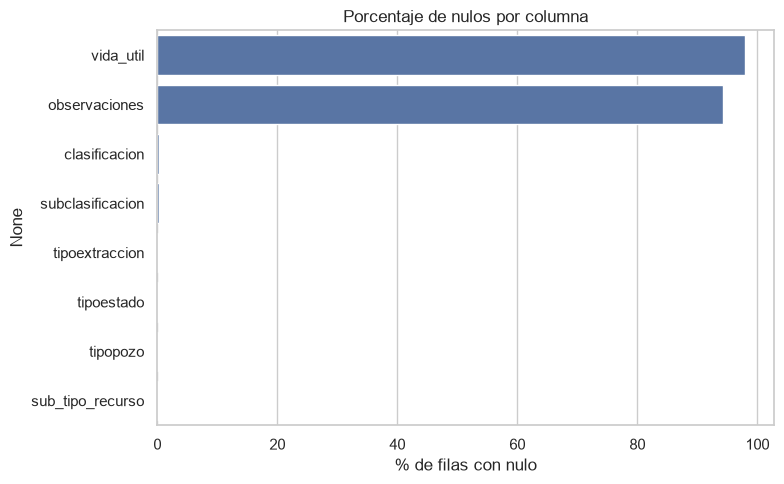

In [18]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct_nulos = (nulos / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=pct_nulos.values, y=pct_nulos.index, ax=ax, color="#4C72B0")
ax.set_xlabel("% de filas con nulo")
ax.set_title("Porcentaje de nulos por columna")
plt.tight_layout()
plt.show()

## 3. Profundidad — distribución y outliers

Sabemos por el diagnóstico que hay un máximo de 378.939 (imposible para un pozo real)
y 122 casos por encima de 10.000. Veamos la forma de la distribución completa y
después con zoom en el rango físicamente plausible.

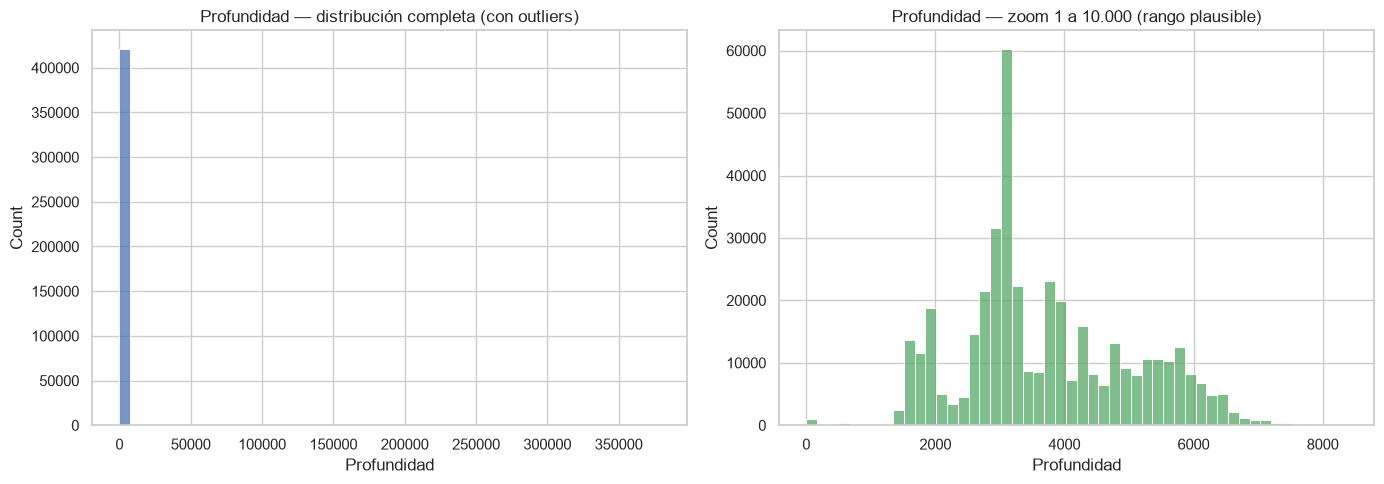

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["profundidad"].dropna(), bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Profundidad — distribución completa (con outliers)")
axes[0].set_xlabel("Profundidad")

rango_plausible = df[df["profundidad"].between(1, 10000)]["profundidad"]
sns.histplot(rango_plausible, bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Profundidad — zoom 1 a 10.000 (rango plausible)")
axes[1].set_xlabel("Profundidad")

plt.tight_layout()
plt.show()

In [20]:
# Los 122 casos sospechosos: ¿tienen algún patrón común?
# (misma empresa, mismo pozo repetido, un dígito de más, etc.)
sospechosos = df[df["profundidad"] > 10000]
print(f"Casos sospechosos: {len(sospechosos)}")
sospechosos[["idempresa", "idpozo", "anio", "mes", "profundidad", "formacion"]].sort_values(
    "profundidad", ascending=False
).head(20)

Casos sospechosos: 122


,idempresa,idpozo,anio,mes,profundidad,formacion
337,YSUR,156804,2018,1,378939.0,lajas
203498,YPF,156804,2023,11,378939.0,lajas
194652,YPF,156804,2023,10,378939.0,lajas
193383,YPF,156804,2020,10,378939.0,lajas
193077,YPF,156804,2019,10,378939.0,lajas
189327,YPF,156804,2021,10,378939.0,lajas
188537,YPF,156804,2018,10,378939.0,lajas
184192,YPF,156804,2024,10,378939.0,lajas
181622,YPF,156804,2022,10,378939.0,lajas
177847,YPF,156804,2024,9,378939.0,lajas


In [21]:
# Profundidad = 0: ¿son pozos distintos o el mismo pozo repetido mes a mes?
ceros = df[df["profundidad"] == 0]
print(f"Filas con profundidad = 0: {len(ceros)}")
print(f"Pozos únicos con profundidad = 0: {ceros['idpozo'].nunique()}")

Filas con profundidad = 0: 5738
Pozos únicos con profundidad = 0: 164


## 4. Producción — distribución y valores negativos

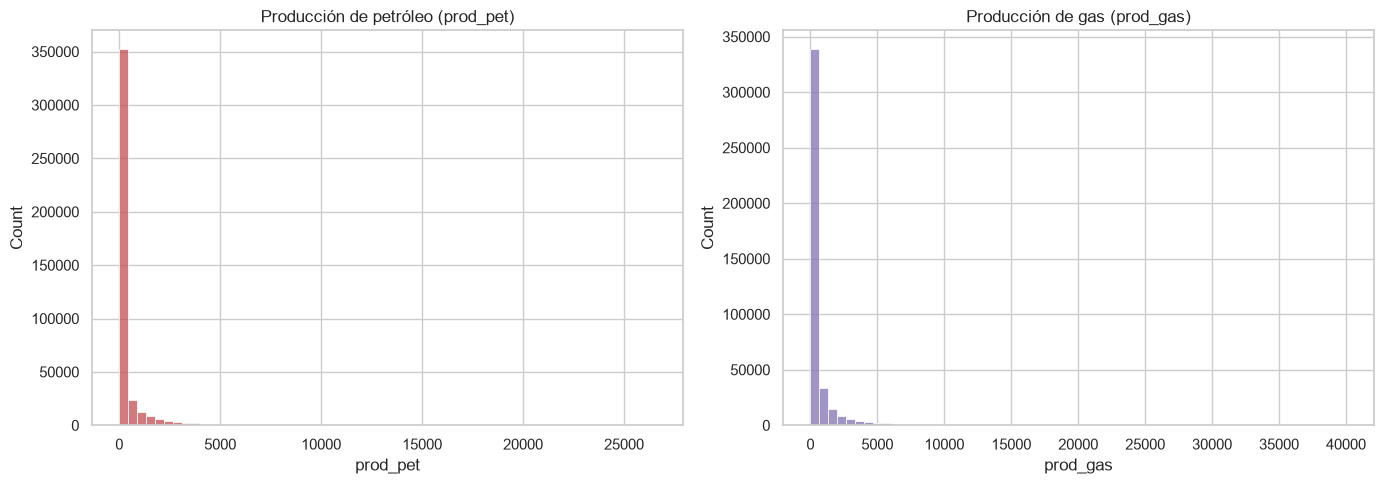

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["prod_pet"], bins=60, ax=axes[0], color="#C44E52")
axes[0].set_title("Producción de petróleo (prod_pet)")

sns.histplot(df["prod_gas"], bins=60, ax=axes[1], color="#8172B2")
axes[1].set_title("Producción de gas (prod_gas)")

plt.tight_layout()
plt.show()

In [23]:
negativos = df[(df["prod_pet"] < 0) | (df["prod_gas"] < 0)]
negativos[["idempresa", "idpozo", "anio", "mes", "prod_pet", "prod_gas"]]

,idempresa,idpozo,anio,mes,prod_pet,prod_gas
300275,PLU,153228,2020,5,1.670,-12.267
300283,PLU,153227,2020,5,1.020,-7.519
323445,PBE,73804,2008,12,-0.001,0.000


## 5. Boxplots por variable clave

Para detectar outliers de forma más sistemática (no solo en profundidad).

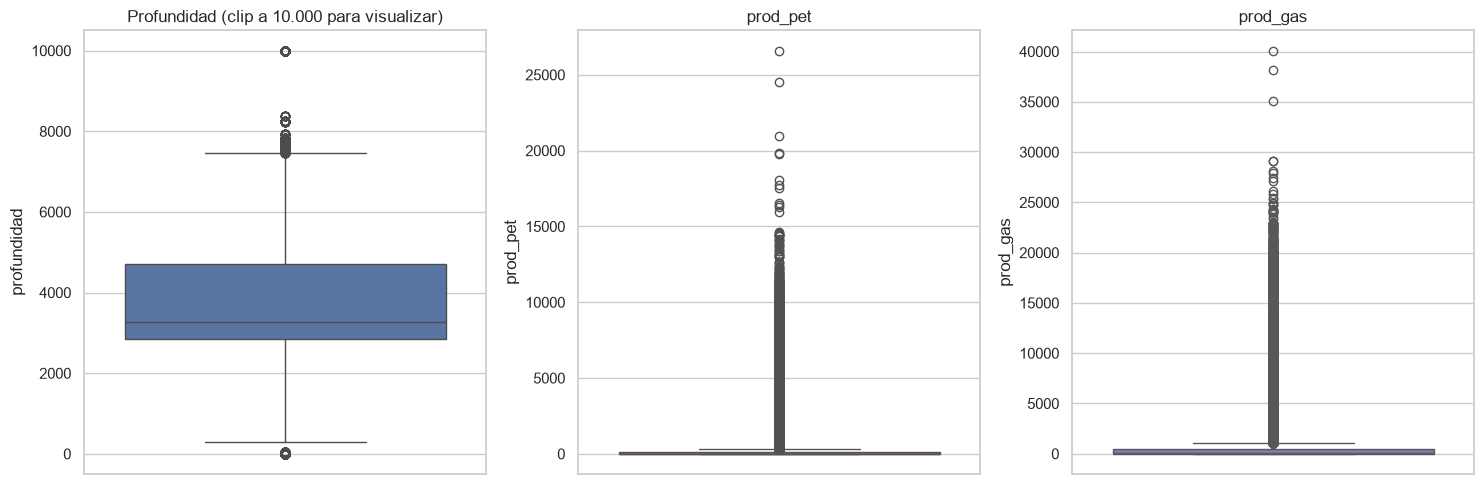

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["profundidad"].clip(upper=10000), ax=axes[0], color="#4C72B0")
axes[0].set_title("Profundidad (clip a 10.000 para visualizar)")

sns.boxplot(y=df["prod_pet"], ax=axes[1], color="#C44E52")
axes[1].set_title("prod_pet")

sns.boxplot(y=df["prod_gas"], ax=axes[2], color="#8172B2")
axes[2].set_title("prod_gas")

plt.tight_layout()
plt.show()

## 6. Evolución temporal — producción total por año (datos crudos)

Ojo: el año 2026 va a aparecer con una caída artificial porque el dataset
todavía no tiene los 12 meses cargados para ese año (no es una caída real
de producción). Lo corregimos en la sección 8.

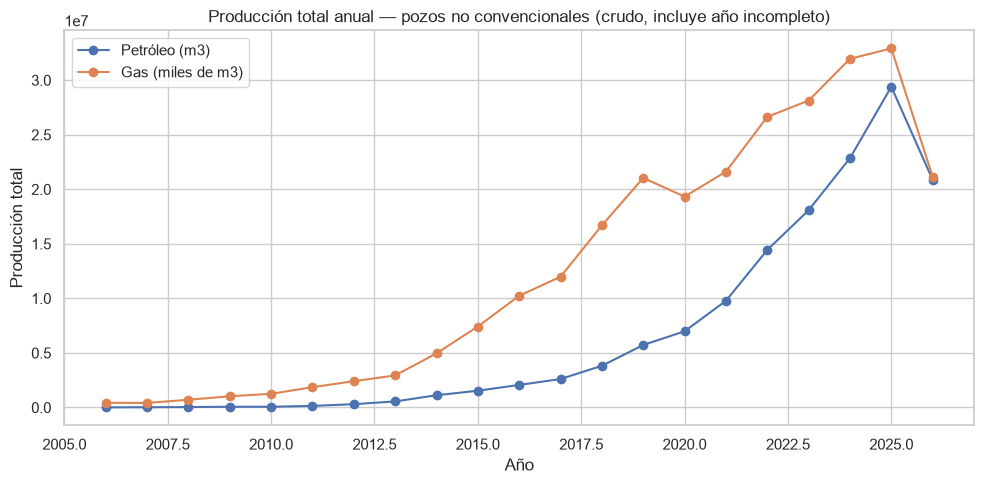

In [25]:
prod_anual = df.groupby("anio")[["prod_pet", "prod_gas"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(prod_anual["anio"], prod_anual["prod_pet"], marker="o", label="Petróleo (m3)")
ax.plot(prod_anual["anio"], prod_anual["prod_gas"], marker="o", label="Gas (miles de m3)")
ax.set_xlabel("Año")
ax.set_ylabel("Producción total")
ax.set_title("Producción total anual — pozos no convencionales (crudo, incluye año incompleto)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusiones del diagnóstico (antes de limpiar)

- **Nulos:** `vida_util` (~98%) y `observaciones` (~94%) se descartan por falta de datos.
  El resto de los nulos categóricos es mínimo (<0.25%) y se imputa con la moda.
- **Profundidad:** los 122 casos sospechosos (>10.000) resultaron ser **un único pozo**
  (idpozo 156804, formación "lajas") con un valor de carga inválido repetido en todos
  sus registros mensuales — no ruido disperso. Los 5.738 registros con profundidad = 0
  corresponden a 164 pozos distintos sin ese dato cargado. Ambos casos se tratan como
  faltantes y se imputan por mediana según formación.
- **Producción negativa:** solo 3 filas, volumen insignificante — se clipean a 0.
- **Año 2026 incompleto:** se excluye de los análisis de tendencia anual para no
  mostrar una caída de producción que en realidad es solo falta de meses cargados.

Reglas trasladadas a `src/preprocessor.py` (`pipeline_preprocesamiento`).

## 8. Verificación post-limpieza

Aplicamos `pipeline_preprocesamiento()` y volvemos a graficar profundidad y la
serie temporal (excluyendo el año incompleto) para confirmar visualmente que las
correcciones tienen sentido.

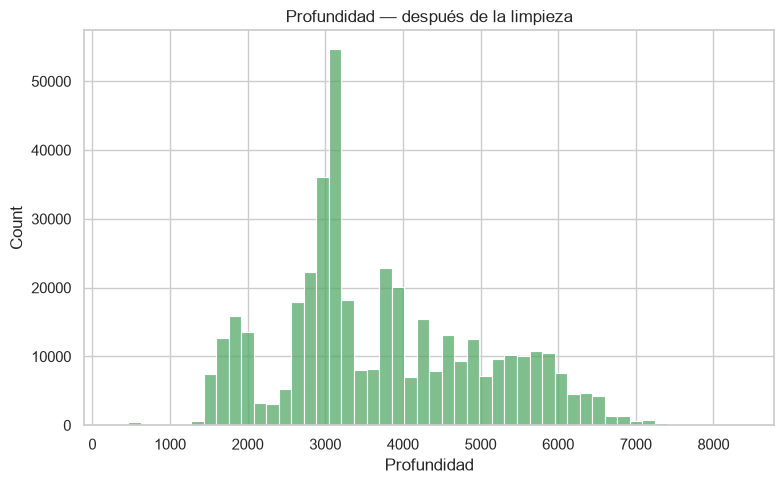

In [26]:
from src.preprocessor import pipeline_preprocesamiento

df_limpio = pipeline_preprocesamiento(df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_limpio["profundidad"], bins=50, ax=ax, color="#55A868")
ax.set_title("Profundidad — después de la limpieza")
ax.set_xlabel("Profundidad")
plt.tight_layout()
plt.show()

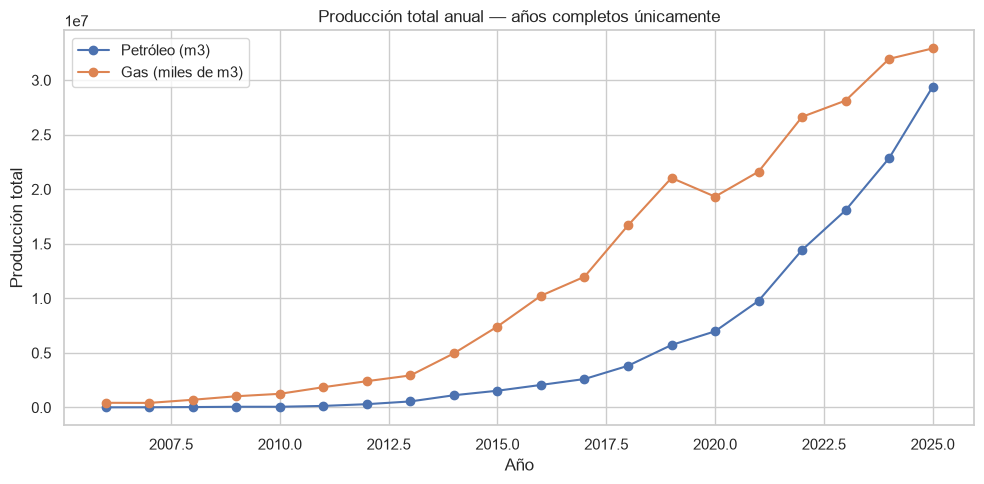

In [27]:
prod_anual_limpia = (
    df_limpio[df_limpio["anio_completo"]]
    .groupby("anio")[["prod_pet", "prod_gas"]]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(prod_anual_limpia["anio"], prod_anual_limpia["prod_pet"], marker="o", label="Petróleo (m3)")
ax.plot(prod_anual_limpia["anio"], prod_anual_limpia["prod_gas"], marker="o", label="Gas (miles de m3)")
ax.set_xlabel("Año")
ax.set_ylabel("Producción total")
ax.set_title("Producción total anual — años completos únicamente")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Conclusión final

La limpieza aplicada en `preprocessor.py` resolvió correctamente las anomalías
detectadas: la distribución de profundidad quedó dentro de rangos físicamente
plausibles, y la serie temporal muestra el crecimiento exponencial esperado de
Vaca Muerta 2006-2025 sin la caída artificial del año incompleto.

**Próximo paso:** `02_feature_engineering.ipynb`.